##### Imports and Settings

In [498]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [499]:
# Imports
from copy import deepcopy
from enum import Enum

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import HTML, Video
from matplotlib.animation import FFMpegWriter, FuncAnimation
from pydmd import BOPDMD, DMD, HAVOK, FbDMD, HankelDMD
from pydmd.plotter import plot_eigs, plot_summary
from pydmd.preprocessing import hankel_preprocessing
from safetensors.torch import load_model
from torch.nn import MSELoss
from torch.optim import SGD
from torch.utils.data import DataLoader
from torchinfo import summary

from algo.embedding import hankel, make_hankel_matrix
from algo.lda import lda
from algo.mean_classifier import mean_classifier
from data import (
    GaussianDataset,
    LinearGaussianDataset,
    RectangularDataset,
    SpiralDataset,
    YinYangDataset,
)
from ast import literal_eval
from models.perceptron import MLP, HiddenLayerModel, SingleNeuronModel, init_weights
from visualization.boundary import extract_layer_weights, plot_decision_boundary_movie
from huggingface_hub import parse_safetensors_file_metadata
from saved_weights import parser

# Make sure you have the correct matplotlib backend
%matplotlib inline

In [500]:
# Custom formatter function
def my_formatter(x):
    if abs(x) < 1e-0 or abs(x) >= 1e0:  # Threshold for scientific notation
        return f"{x:.2e}"  # Format as scientific with 2 decimal places
    else:
        return f"{x:.2f}"  # Format as decimal with 2 decimal places


# Set print options with custom formatter
torch.set_printoptions(linewidth=100, sci_mode=True)
np.set_printoptions(linewidth=100, formatter={"float_kind": my_formatter})

##### Model and Dataset Load

In [501]:
file_path = "../saved_weights/model.safetensors"
metadata = parser.safetensors_metadata_parser(file_path=file_path)

model = MLP(config=literal_eval(metadata["config"]))
load_model(model, file_path, device="cuda:0")

model

MLP(
  (features): Sequential(
    (0): Linear(in_features=2, out_features=10, bias=False)
    (1): Tanh()
    (2): Linear(in_features=10, out_features=10, bias=False)
    (3): Tanh()
    (4): Linear(in_features=10, out_features=1, bias=False)
    (5): Tanh()
  )
)

In [502]:
PROBLEM = metadata["dataset"]
NUM_SAMPLES = 1_000
NUM_GAUSS_FEATURES = 0

# Build dataset
if PROBLEM == "yinyang":
    dataset = YinYangDataset(size=NUM_SAMPLES)
else:
    raise NotImplementedError()

In [503]:
# a dict to store the activations
activation_dict = {}

In [504]:
def getActivation(name):
    # the hook signature
    def hook(model, input, output):
        activation_dict[name] = output.detach()

    return hook

In [505]:
h1_name = "pre_layer"
h2_name = "post_layer"

h1 = model.features[1].register_forward_hook(getActivation(h1_name))
h2 = model.features[3].register_forward_hook(getActivation(h2_name))

out = model(dataset.features)

h1.remove()
h2.remove()

In [506]:
sample_size = 100
num_samples = dataset.features.shape[0]


all_indices = np.arange(num_samples)
train_indices = np.random.choice(
    dataset.features.shape[0], size=sample_size, replace=False
)
test_indices = np.random.choice(
    np.setdiff1d(all_indices, train_indices), size=sample_size, replace=False
)

In [507]:
pre_act = activation_dict[h1_name].cpu().numpy()
flat_pre_act = np.expand_dims(pre_act[train_indices, :].flatten(), axis=1)
flat_pre_act.shape

(1000, 1)

In [508]:
post_act = activation_dict[h2_name].cpu().numpy()
flat_post_act = np.expand_dims(post_act[train_indices, :].flatten(), axis=1)
flat_post_act.shape

(1000, 1)

In [509]:
print(train_indices, test_indices)

[500 762 908 694 238  73 225 604 429 279 703 335 143 978 812 876 239 872 941 234 618 482 379 496
  10 126 440 310 940 235 737 647 934 266 595 996 758  76 295 696 405 800 776 557   7 419  88  25
 877 203 437 376 942  65 894  51 755 475 498 452 939  98 913 918 565 156 200 955 829 543 811 611
 746 581 300 726 275 269 486 120 520 183  35 161 467 159 371 378 553 291 706   6 288 563 840 643
 509 937 382  84] [693 588 756 546 533 857 668 602 816 114 550 589 936 511 856 134 407 549 594  58 198 848 654 624
 626 632 830 720 875 157 861 331 449 727 544 682 645  56 173 834 807 391 813 146 850 320 605 619
 309 305 751 889 719 236 425 314 759 380 175  59 629 767   0 609 558 741 411 152 209 723 515 369
 596 890 798 960 153 615 341  17 280 648 504 853  47 184  37 820 139 915 567 883 699 224 435 393
 678 909 111 502]


In [510]:
catted = np.concatenate(
    (flat_pre_act, flat_post_act),
    axis=1,
)
HEAD = 10
catted[:HEAD, :]

array([[-6.19e-01, 9.80e-01],
       [6.49e-01, 8.30e-01],
       [6.52e-01, -1.00e+00],
       [-1.00e+00, 9.46e-01],
       [-6.41e-01, -3.58e-01],
       [8.27e-01, -8.85e-01],
       [6.37e-01, -7.19e-04],
       [-6.40e-01, -8.02e-01],
       [6.43e-01, -9.44e-01],
       [-6.18e-01, -3.13e-01]], dtype=float32)

In [511]:
REPS = 5
tiled = np.tile(catted, reps=(1, REPS))
tiled.shape

(1000, 10)

Layer Extraction 

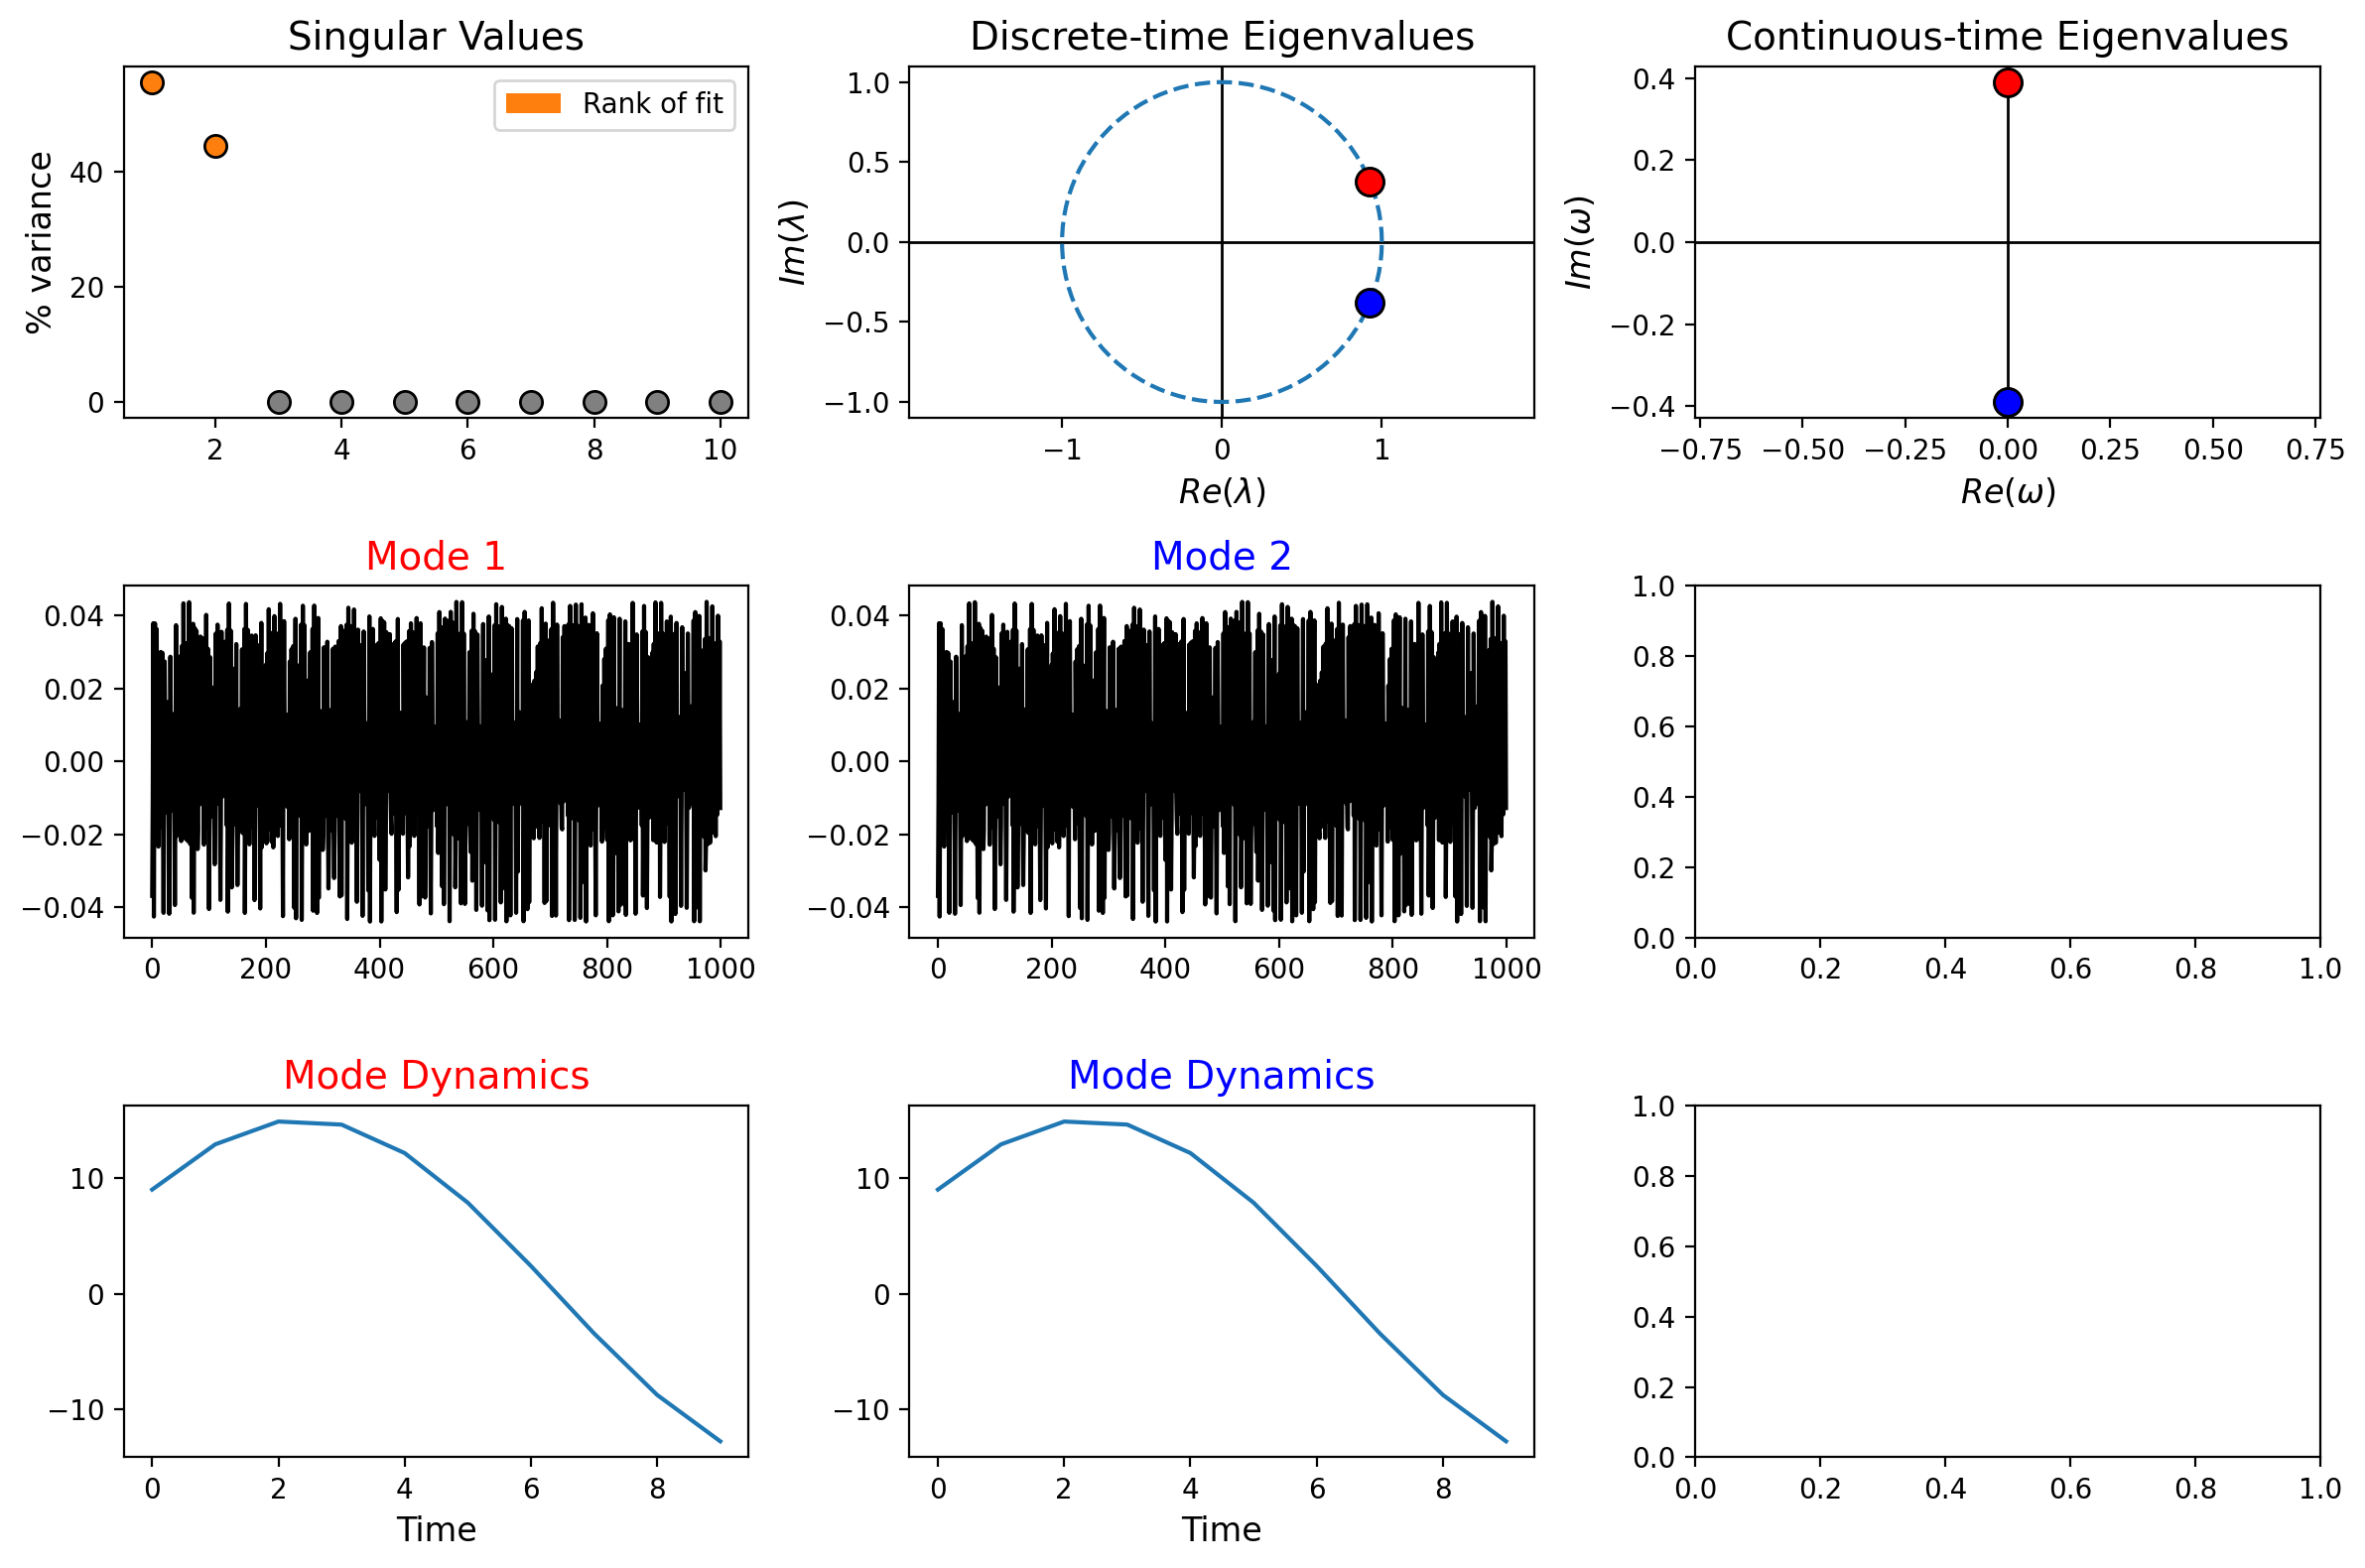

In [512]:
dmd = FbDMD(svd_rank=2)
dmd.fit(X=tiled)

plot_summary(dmd, index_modes=[0, 1, 2], order="F")

In [513]:
test_catted = np.concatenate(
    (
        np.expand_dims(pre_act[test_indices, :].flatten(), axis=1),
        np.expand_dims(post_act[test_indices, :].flatten(), axis=1),
    ),
    axis=1,
)

In [514]:
test_catted[:HEAD]

array([[-7.67e-01, 9.98e-01],
       [7.25e-01, 6.14e-01],
       [7.13e-01, -1.00e+00],
       [-1.00e+00, 9.62e-01],
       [-6.65e-01, -4.51e-01],
       [6.39e-01, -6.53e-01],
       [6.54e-01, -4.80e-02],
       [-7.13e-01, -8.94e-01],
       [7.06e-01, -5.90e-01],
       [-7.76e-01, -4.66e-01]], dtype=float32)

In [515]:
predicted = dmd.predict(X=test_catted[:, 0]).real

In [516]:
predicted[:HEAD]

array([-7.09e-01, 2.14e-01, 7.38e-01, -9.65e-01, -3.43e-01, 8.27e-01, 4.43e-01, -2.16e-01,
       7.16e-01, -3.40e-01], dtype=float32)